In [4]:
from spectral_core import (
    SpectralDataset,
    PreprocessingPipeline, 
    SavitzkyGolayFilter, 
    Normalization, 
    RegionSelector, 
    SampleFilter,
    DataSplitter
)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [6]:
OUTPUT_DIR = '../data/processed/'
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

In [7]:
dataset = SpectralDataset.from_csv(
    file_path='../data/dataset_681.csv',
    wavenumbers_path='../data/wavenumbers.csv',
)

In [8]:
dataset.summary()

### Spectral Dataset Summary
- **Samples:** 681
- **Features:** 7467 wavenumbers
- **Range:** 400.6 - 4000.2 cm⁻¹

,Mean,Std,Min,Max
HbA1c,7.366579,2.443136,3.57,17.06
Age,57.944200,15.904814,0.00,92.00


(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'Spectra colored by HbA1c'}, xlabel='Wavenumbers (cm⁻¹)', ylabel='Absorbance'>)

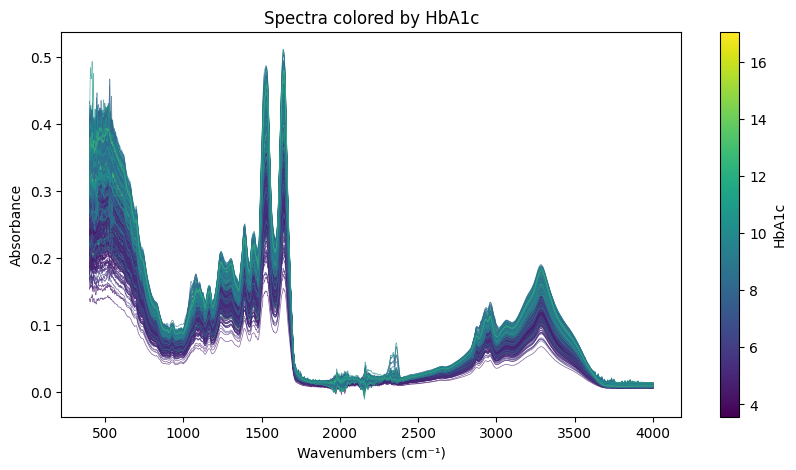

In [9]:
dataset.plot_spectra(feature="HbA1c")

In [10]:
pipeline = PreprocessingPipeline([
    SampleFilter(feature_max={"HbA1c": 14.0}, exclude_indices=[287, 636]),
    SavitzkyGolayFilter(window_length=33, polyorder=2, deriv=1),
    Normalization(method='vector'),
    RegionSelector(regions=[(800, 1800), (2800, 3400)])
])

preprocessed_data = pipeline.apply(dataset)

(<Figure size 1000x500 with 4 Axes>, <brokenaxes.BrokenAxes at 0x7fc9b49a1d50>)

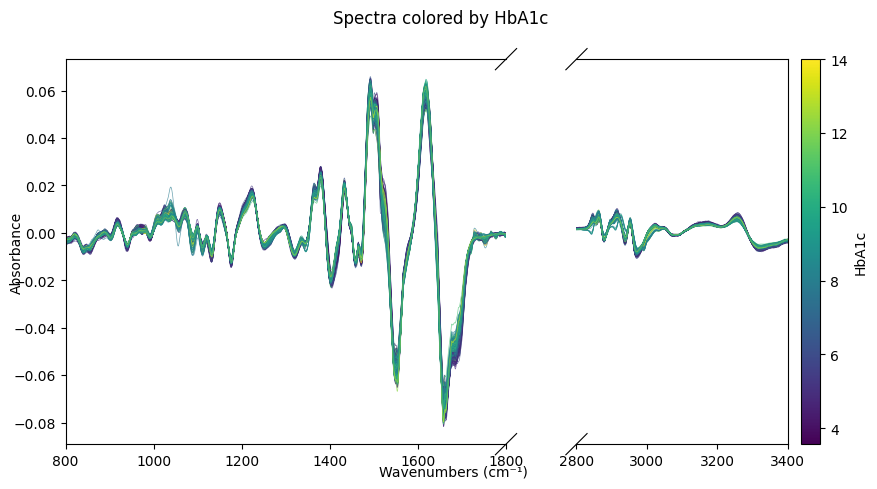

In [11]:
preprocessed_data.plot_spectra(feature="HbA1c")

In [12]:
splitter = DataSplitter(
    test_size=0.2,
    val_size=0.2,
    random_state=34
)
split = splitter.train_val_test_split(preprocessed_data)

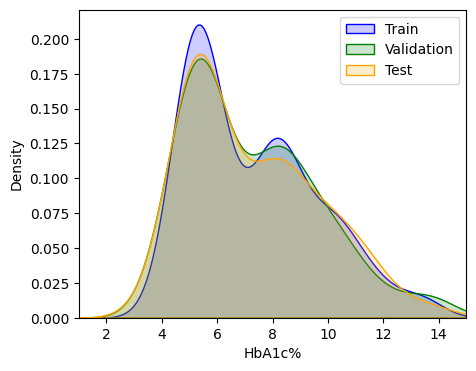

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.kdeplot(split.train.get_feature('HbA1c'), ax=ax, color='blue', fill=True, alpha=0.2, label='Train')
sns.kdeplot(split.val.get_feature('HbA1c'), ax=ax, color='green', fill=True, alpha=0.2, label='Validation')
sns.kdeplot(split.test.get_feature('HbA1c'), ax=ax, color='orange', fill=True, alpha=0.2, label='Test')

ax.set_xlabel('HbA1c%')
ax.set_xlim([1, 15])
ax.legend()

In [14]:
split.val.spectra.shape

(135, 3319)

In [15]:
split.test.spectra.shape

(135, 3319)

In [16]:
split.train.spectra.shape

(403, 3319)

In [17]:
splitter.save_split(
    split,
    output_dir=OUTPUT_DIR
)

Data split saved to /home/mykola/projects/ftir-hba1c-prediction/data/cnn/
  Train samples: 403
  Val samples: 135
  Test samples: 135
